### Notebook to compare ORCESTRA sounding statistics from different sources.

James Ruppert  
jruppert@ou.edu  
2/10/25

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import seaborn as sns
import warnings
import xarray as xr
warnings.filterwarnings('ignore')

### Read in data

#### Data from IPFS server

In [2]:
#############################################
### Functions for reading from IPNS
#############################################

orcestra_ipns_root = "ipns://latest.orcestra-campaign.org"

def get_ipfs_data(path, var):
    ds = xr.open_dataset(f"{orcestra_ipns_root}/products/{path}", engine="zarr")
    data = ds[var].data
    try:
        times = ds[var].time.data
    except:
        times = ds[var].TIME.data
    ds.close()
    return np.array(data), times

def read_soundings(platform='RV_Meteor', ascent=0):

    path = 'Radiosondes/Level_2/RAPSODI_RS_ORCESTRA_level2.zarr'
    sndfile = xr.open_dataset(f"{orcestra_ipns_root}/products/{path}", engine="zarr")
    # Print unique platforms
    # print(np.unique(platform))
    # hght = np.squeeze(sndfile['alt'].data) # m
    hght = np.squeeze(sndfile['height'].data) # m
    platform = sndfile.variables['platform'].data
    ascent_flag = sndfile.variables['ascent_flag'].data # 0, 1 --> ascent, descent
    isondes = (platform == 'RV_Meteor') & (ascent_flag == ascent)
    times = sndfile['launch_time'][isondes].data
    nt = len(times)

    p    = np.ma.masked_invalid(np.squeeze(sndfile['p'][isondes].data))    # Pa
    tmpk = np.ma.masked_invalid(np.squeeze(sndfile['ta'][isondes].data))   # K
    rh   = np.ma.masked_invalid(np.squeeze(sndfile['rh'][isondes].data))*1e2 # 0-1 --> %
    mr   = np.ma.masked_invalid(np.squeeze(sndfile['mr'][isondes].data))   # kg/kg
    # q[ifile,:]    = np.ma.masked_invalid(np.squeeze(sndfile['q'].data))   # kg/kg
    wdir = np.ma.masked_invalid(np.squeeze(sndfile['wdir'][isondes].data)) # deg
    u    = np.ma.masked_invalid(np.squeeze(sndfile['u'][isondes].data))    # m/s
    v    = np.ma.masked_invalid(np.squeeze(sndfile['v'][isondes].data))    # m/s
    sndfile.close()
    hght_0c= np.full(nt, np.nan)
    for isnd in range(nt):
        try:
            hght_0c[isnd]= hght[ np.where(tmpk[isnd,:] <= 273.15)[0][0] ]
        except:
            continue
        hght_0c[isnd]= hght[ np.where(tmpk[isnd,:] <= 273.15)[0][0] ]
    inan = np.where(hght_0c > 8000)[0]
    hght_0c[inan] = np.nan
    lat= np.ma.masked_invalid(np.squeeze(sndfile['launch_lat'][isondes].data))   # deg N
    lon= np.ma.masked_invalid(np.squeeze(sndfile['launch_lon'][isondes].data))   # deg

    soundings = {
        'times': times,
        'lon':lon,
        'lat':lat,
        'hght':hght,
        'hght_0c':np.ma.masked_invalid(hght_0c),
        'p': p,
        'tmpk': tmpk,
        'rh': rh,
        'mr': mr,
        # 'q': q,
        'u': u,
        'v': v,
        'wdir': wdir,
    }

    return soundings

def read_halo_soundings_lev3():
    # path = "HALO/dropsondes/Level_3/PERCUSION_Level_3.zarr"
    path = "HALO/dropsondes/Level_3"
    ds = xr.open_dataset(f"{orcestra_ipns_root}/products/{path}", engine="zarr")
    time = ds["launch_time"].data
    qual_flag = ds["sonde_qc"].data # 0, 1, 2 --> good, bad, ugly
    # Put variables into dictionary
    snd_halo = {}
    snd_halo["times"] = time
    snd_halo["hght"] = np.ma.masked_invalid(ds["altitude"].data) # m
    snd_halo["lat"]  = np.ma.masked_invalid(ds["launch_lat"].data) # deg
    snd_halo["lon"]  = np.ma.masked_invalid(ds["launch_lon"].data) # deg
    snd_halo["p"]    = np.ma.masked_invalid(ds["p"].data) # Pa
    sh               = np.ma.masked_invalid(ds["q"].data) # specific humidity, kg/kg
    # Convert SH to MR for consistency with METEOR soundings
    snd_halo["mr"] = sh / (1 - sh) # mixing ratio, kg/kg
    snd_halo["tmpk"] = np.ma.masked_invalid(ds["ta"].data) # K
    snd_halo["u"]    = np.ma.masked_invalid(ds["u"].data) # m/s
    snd_halo["v"]    = np.ma.masked_invalid(ds["v"].data) # m/s
    ds.close()
    # Drop values depending on quality flag
    flag_value = 0
    indices1d = (qual_flag == flag_value).nonzero()
    indices1d_not = (qual_flag != flag_value).nonzero()
    time = np.array(time)[indices1d]
    for key in snd_halo.keys():
        if key == "hght":
            continue
        if snd_halo[key].ndim == 2:
            snd_halo[key] = np.delete(snd_halo[key], indices1d_not, axis=0)
        elif (snd_halo[key].ndim == 1) and (snd_halo[key].shape[0] == qual_flag.shape[0]):
            snd_halo[key] = snd_halo[key][indices1d]
        else:
            raise ValueError(f"Unexpected number of dimensions for {key}: shape is {snd_halo[key].shape}")
    return snd_halo

#############################################
### Mask sounding data
#############################################

# Mask soundings that don't reach (default) 100 hPa
def mask_soundings(soundings, p_threshold=100): # p_threshold should be in hPa
    import copy
    # First save minimum pressure
    nt = soundings['p'].shape[0]
    min_pres = np.full(nt, np.nan)
    soundings_masked = copy.deepcopy(soundings)
    for isnd in range(nt):
        min_pres[isnd] = np.nanmin(soundings['p'][isnd,:]*1e-2) # Pa --> hPa
        if min_pres[isnd] > p_threshold:
            for key in soundings.keys():
                try:
                    soundings_masked[key][isnd,:] = np.nan
                except:
                    continue
    return soundings_masked, min_pres

In [3]:
# Radiometer data
path = 'METEOR/HATPRO/hatpro_single.zarr'
var = "iwv"
cwv_rdm, times_rdm = get_ipfs_data(path, var)
var = "iwv_quality_flag"
cwv_qflag, times_rdm = get_ipfs_data(path, var)
cwv_rdm[np.where(cwv_qflag != 0)] = np.nan

# GPS water vapor
path = "METEOR/GNSS_IWV.zarr"
var = "iwv"
cwv_gps, times_gps = get_ipfs_data(path, var)

# Sun photometer data
path = "METEOR/Sunphotometer/AOD/Meteor_24_0_all_points.lev20.zarr"
var = "water_vapor(cm)"
photom, times_photom = get_ipfs_data(path, var)
photom*=10 # Convert cm to mm

# HALO dropsondes
snd_halo = read_halo_soundings_lev3()
nt_halo = len(snd_halo['times'])
min_pres_halo = np.full(nt_halo, np.nan)
for isnd in range(nt_halo):
    min_pres_halo[isnd] = np.nanmin(snd_halo['p'][isnd,:]*1e-2) # Pa --> hPa

# BCO soundings
snd_bco = read_soundings(platform='BCO')
# SAL soundings
snd_sal = read_soundings(platform='INMG')
# Meteor soundings
snd_meteor = read_soundings(platform='RV_Meteor')

# Mask soundings that don't reach 100 hPa
snd_meteor, min_pres_meteor = mask_soundings(snd_meteor, p_threshold=100)

/Users/jamesruppert/miniforge3/envs/plotting/lib/python3.11/site-packages/numcodecs/__init__.py:106: DeprecationWarning: crc32c usage is deprecated since numcodecs v0.16.4. It is recommended to install google_crc32c instead.
  from numcodecs.checksum32 import CRC32, Adler32, JenkinsLookup3


#### Local data

In [ ]:
# Read in cloud/rain conditions
# based on rain gauge, cielometer, cloud radar
cloud_mask_ds = xr.open_dataset('../processed_data/BOWTIE_sky_condition_classification.nc')
cloud_mask_ds
cloud_mask = cloud_mask_ds['classification_sky'].values
times_cloud_mask = cloud_mask_ds['time'].values
cloud_mask_ds.close()

### Vertically integrate water vapor

In [5]:
# Compute CWV
def vert_integral(data, zbase=0, set_nans=True):
    def mixr2sh(mixr):
        q = mixr / (1 + mixr)
        return q
    p = np.ma.filled(data['p'], np.nan)
    t = np.ma.filled(data['tmpk'], np.nan)
    hght = data['hght']
    if hght.ndim == 1:
        iz = np.where(hght >= zbase)[0]
        hght = np.repeat(hght[np.newaxis,:], p.shape[0], axis=0)
    else:
        iz = np.where(hght[0,:] >= zbase)[0]
    try:
        sh = data['sh']
        # mr = sh2mixr(sh)
    except:
        mr = data['mr']
        sh = mixr2sh(mr)
    # rho = density_moist(t, sh, p) # kg/m3
    rd=287.04
    rv=461.5
    eps_r=rv/rd
    # The two forms of rho below are identical, just using r vs q
    # rho = p / ( rd * t * (1. + mr*eps_r)/(1.+mr) )
    # Below is the form of Schulz and Stevens (2018)
    rho = p / ( rd * t * (1 + sh*(eps_r - 1)) )
    cwv = np.trapezoid(sh[:,iz] * rho[:,iz], hght[:,iz], axis=1)
    # cwv = np.nansum((rho[:,iz] * sh[:,iz] * np.gradient(hght[:,iz], axis=1)), axis=1)
    # Replace NaNs
    if set_nans:
        nans = np.where(np.isnan(p[:,5]))
        cwv[nans] = np.nan
    return cwv

# Interpolates nearest values to match times_out from times_in.
def interpolate_nearest(times_in, times_out, var):
    t_in = np.asarray(times_in, dtype='datetime64[ns]')
    t_out = np.asarray(times_out, dtype='datetime64[ns]')

    t_in_ns = t_in.astype('int64')
    t_out_ns = t_out.astype('int64')

    idx_right = np.searchsorted(t_in_ns, t_out_ns, side='left')
    idx_left = np.clip(idx_right - 1, 0, len(t_in_ns) - 1)
    idx_right = np.clip(idx_right, 0, len(t_in_ns) - 1)

    d_left = np.abs(t_out_ns - t_in_ns[idx_left])
    d_right = np.abs(t_in_ns[idx_right] - t_out_ns)
    nearest_idx = np.where(d_left <= d_right, idx_left, idx_right)

    out = np.asarray(var)[nearest_idx].astype(float)
    out[np.isnat(t_out)] = np.nan
    return out

# Interpolates the cloud mask to match the times of the input soundings.
def interpolate_cloud_mask(times_cloud_mask, cloud_mask, times_output):
    return interpolate_nearest(times_cloud_mask, times_output, cloud_mask)

In [6]:
# CWV aka IWV aka PW
# cwv_meteor = vert_integral(snd_meteor)
cwv_meteor_30m = vert_integral(snd_meteor, zbase=30)
cwv_bco = vert_integral(snd_bco)
cwv_sal = vert_integral(snd_sal)

---
### Plotting

#### Plotting functions

In [7]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 12}

rc('font', **font)

In [8]:
def plot_cwv_kde_cm(legends, cwvs_nested, cm_tags):

    # sns.set_theme(style="darkgrid", rc={'xtick.bottom': True, 'ytick.left': True,})
    sns.set_theme(style="ticks", rc={'xtick.bottom': True, 'ytick.left': True, "axes.spines.right": False, "axes.spines.top": False})
    # sns.set_theme(style="dark")

    fig_x = 6
    fig_y = 10
    nrows = len(cwvs_nested)
    fig, ax = plt.subplots(nrows,1, figsize=(fig_x,fig_y), layout='constrained', squeeze=True)
    # plt.suptitle(title)
    for i, iax in enumerate(ax):
        iax.set_title(cm_tags[i])
        iax.set_ylabel('Density')
        sns.despine(offset=10,ax=iax)#, left=True, bottom=False)
        iax.set_xlim(32, 77)

    default_colors = sns.color_palette('muted', n_colors=len(legends))
    # default_colors = sns.color_palette()

    for (iax, cwv_group) in zip(ax, cwvs_nested):

        # Save meteor mean to get the difference
        meteor_mean = np.nanmean(cwv_group[0])

        for i, (icwv, legend) in enumerate(zip(cwv_group, legends)):
            mean = np.nanmean(icwv)
            diff_from_meteor = mean - meteor_mean
            diff_from_meteor = str(np.round(diff_from_meteor,2))
            if i > 0:
                legend = legend+r' ($\Delta= $'+diff_from_meteor+')'
            else:
                legend = legend+r' (N = '+str(np.sum(np.isfinite(icwv)))+')'
            # Kernel Density Estimate (KDE) plots
            color = default_colors[i]
            # if i == 0:
            #     color='black'
            kde = sns.kdeplot(icwv, ax=iax, label=legend, fill=True, common_norm=True, color=color)
            # Plot vertical line
            lw = 0.7
            iax.axvline(x=mean, color=color, linewidth=lw)

    # Remove tick numbers from all but the last axis
    for iax in ax[:-1]:
        iax.tick_params(labelbottom=False)

    # ax[0].legend(loc='upper left', fontsize='small')
    for iax in ax:
        iax.set_xlabel('')
        iax.legend(fontsize='small', loc='upper left', frameon=False)
    ax[-1].set_xlabel('IWV / kg/m$^2$')
    # plt.legend()
    plt.show()
    # Save figure
    # fig.savefig('cwv_kde_cm.png', dpi=300, bbox_inches='tight')
    fig.savefig('cwv_kde_cm.pdf', dpi=300, bbox_inches='tight')
    plt.close()
    return None

#### All dataset comparison

In [9]:
# Exclude Mindelo data - select times after 16 Aug 2024
# t_start = np.datetime64('2024-08-16T08:00:00')
t_start = np.datetime64('2024-08-17T00:00:00')
t_ind_snd = np.where(snd_meteor['times'] >= t_start)[0]
t_ind_rdm = np.where(times_rdm >= t_start)[0]
t_ind_photom = np.where(times_photom >= t_start)[0]
t_ind_gps = np.where(times_gps >= t_start)[0]
# t_ind_era5v1 = np.where(times_era5 >= t_start)[0]
# t_ind_era5v2 = np.where(times_sonde_era5 >= t_start)[0]

#### Filter by cloud/rain conditions

In [10]:
cm_meteor = interpolate_cloud_mask(times_cloud_mask, cloud_mask, snd_meteor['times'])
cm_rdm = interpolate_cloud_mask(times_cloud_mask, cloud_mask, times_rdm)
cm_photom = interpolate_cloud_mask(times_cloud_mask, cloud_mask, times_photom)
cm_gps = interpolate_cloud_mask(times_cloud_mask, cloud_mask, times_gps)
# cm_era5v2 = interpolate_cloud_mask(times_cloud_mask, cloud_mask, times_sonde_era5)

Cloud mask conditions (from Anna):
1. = Clear sky
2. = probably cloudy
3. = confidently cloudy
4. = rain

(from Anna) So it would be interesting to only use clear sky cases. Or at least non-rainy cases. Cloudy conditions are defined into porbably (when either ceilometer or cloud radar detected a signal) and confidentally cloudy (when both instruments detected a signal). the Probably cloduy situation mostly occured when there were thin liwuid clodus between 4 and 7 km - mostly the radar didnt see these, but the ceilometer could detect a clodu base.

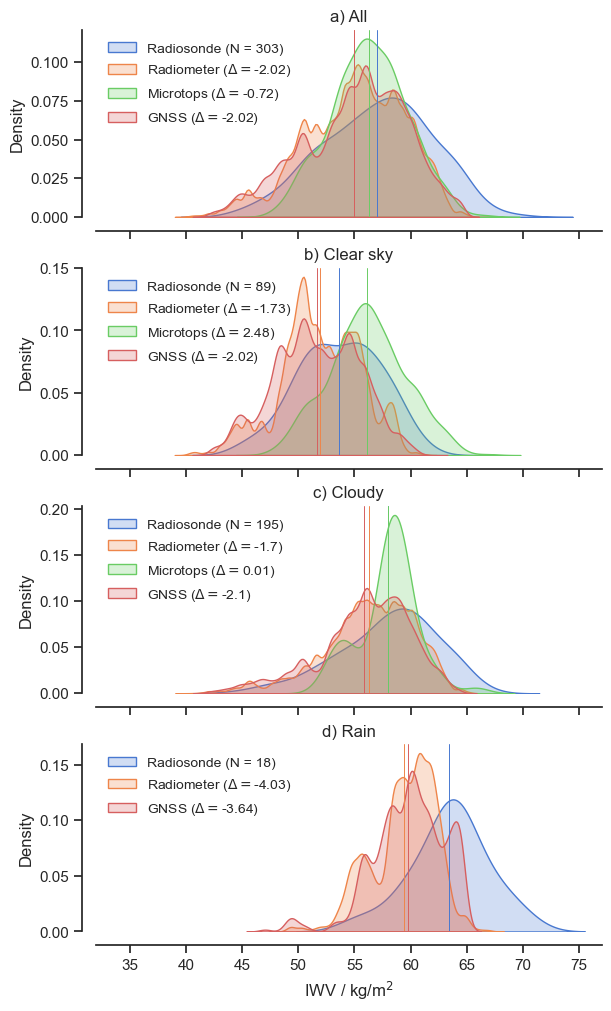

In [11]:
cwv_meteor_select = cwv_meteor_30m
# cwv_meteor_select = cwv_meteor

cwvs_all = [
    cwv_meteor_select[t_ind_snd],
    cwv_rdm[t_ind_rdm],
    photom[t_ind_photom],
    cwv_gps[t_ind_gps],
    # cwv_era5v2[t_ind_era5v2],
]

i_cloud_mask = 1
cm_tag2 = 'Clear sky'
cwvs_cs = [
    cwv_meteor_select[t_ind_snd][np.where(cm_meteor[t_ind_snd] == i_cloud_mask)],
    cwv_rdm[t_ind_rdm][np.where(cm_rdm[t_ind_rdm] == i_cloud_mask)],
    # cwv_rdm_cs_meteortimes,
    (photom[t_ind_photom])[np.where(cm_photom[t_ind_photom] == i_cloud_mask)],
    cwv_gps[t_ind_gps][np.where(cm_gps[t_ind_gps] == i_cloud_mask)],
    # cwv_era5v2[t_ind_era5v2][np.where(cm_era5v2[t_ind_era5v2] == i_cloud_mask)],
]

# i_cloud_mask = 2
cm_tag3 = 'Cloudy'
cwvs_cloudy = [
    cwv_meteor_select[t_ind_snd][np.where((cm_meteor[t_ind_snd] == 2) | (cm_meteor[t_ind_snd] == 3))],
    cwv_rdm[t_ind_rdm][np.where((cm_rdm[t_ind_rdm] == 2) | (cm_rdm[t_ind_rdm] == 3))],
    (photom[t_ind_photom])[np.where((cm_photom[t_ind_photom] == 2) | (cm_photom[t_ind_photom] == 3))],
    cwv_gps[t_ind_gps][np.where((cm_gps[t_ind_gps] == 2) | (cm_gps[t_ind_gps] == 3))],
    # cwv_era5v2[t_ind_era5v2][np.where((cm_era5v2[t_ind_era5v2] == 2) | (cm_era5v2[t_ind_era5v2] == 3))],
]

i_cloud_mask = 4
cm_tag4 = 'Rain'
cwvs_rain = [
    cwv_meteor_select[t_ind_snd][np.where(cm_meteor[t_ind_snd] == i_cloud_mask)],
    cwv_rdm[t_ind_rdm][np.where(cm_rdm[t_ind_rdm] == i_cloud_mask)],
    (photom[t_ind_photom])[np.where(cm_photom[t_ind_photom] == i_cloud_mask)],
    cwv_gps[t_ind_gps][np.where(cm_gps[t_ind_gps] == i_cloud_mask)],
    # cwv_era5v2[t_ind_era5v2][np.where(cm_era5v2[t_ind_era5v2] == i_cloud_mask)],
]

cwvs_nested = [cwvs_all, cwvs_cs, cwvs_cloudy, cwvs_rain]
cm_tags = ['a) All', 'b) '+cm_tag2, 'c) '+cm_tag3, 'd) '+cm_tag4]

legends = [
    'Radiosonde',
    'Radiometer',
    'Microtops',
    'GNSS',
    # 'ERA5-sonde'
    ]

plot_cwv_kde_cm(legends, cwvs_nested, cm_tags)

##### Scatter of Sondes vs other datasets

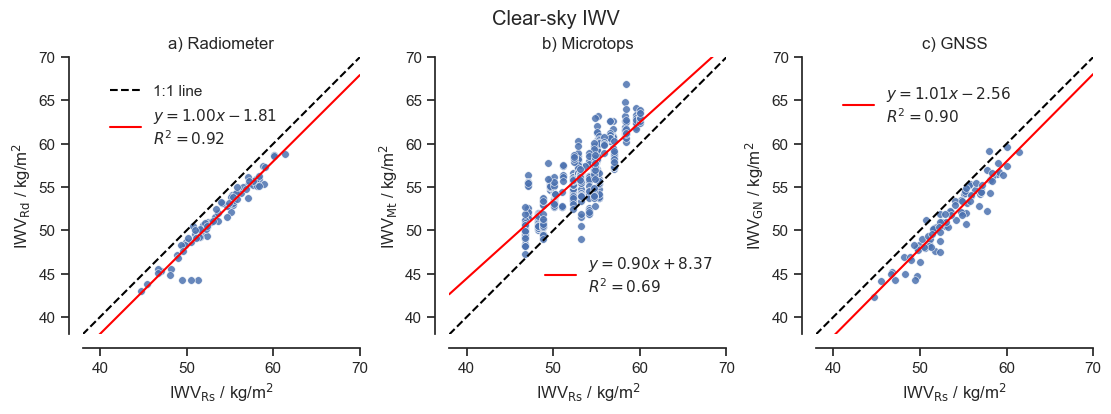

In [12]:
# Now with all datasets

# Plot the scatter of cwv_meteor_select vs. cwv_rdm
def plot_scatter_cwv_meteor_vs_other(cwv_meteor, cwv_rdm, cwv_meteor_photom, photom, cwv_meteor_gps, cwv_gps):
    # Plot scatter plot of CWV from soundings vs. other datasets

    from scipy.stats import linregress

    sns.set_theme(style="ticks", rc={'xtick.bottom': True, 'ytick.left': True, "axes.spines.right": False, "axes.spines.top": False})
    fig_x = 11
    fig_y = 4.
    # fig, axs = plt.subplots(1, 6, figsize=(fig_x, fig_y),
    fig, axs = plt.subplots(1, 3, figsize=(fig_x, fig_y),
                            # width_ratios=[0.85, 0.15, 0.85, 0.15, 0.85, 0.15],
                            layout='constrained', squeeze=True)

    plt.suptitle('Clear-sky IWV')
    subtitles = ['a) Radiometer', 'b) Microtops', 'c) GNSS']
    # ylabel = ['Radiometer', 'Microtops', 'GNSS']
    ylabel = ['IWV$_\mathrm{Rd}$', 'IWV$_\mathrm{Mt}$', 'IWV$_\mathrm{GN}$']
    # for iax, ax in enumerate(axs[[0,2,4]]):
    for iax, ax in enumerate(axs):
        ax.set_xlabel('IWV$_\mathrm{Rs}$ / kg/m$^2$')
        ax.set_ylabel(ylabel[iax]+' / kg/m$^2$')
        ax.set_title(subtitles[iax])

    max_val = 70
    min_val = 38#np.nanmin([np.nanmin(cwv_meteor), np.nanmin(cwv_other)])

    def scatterplot(axs, cwv_meteor, cwv_other, delete_121=False):

        sns.scatterplot(x=cwv_meteor, y=cwv_other, ax=axs, s=30, alpha=0.85)

        # Plot the 1:1 line
        axs.set_xlim(min_val, max_val)
        axs.set_ylim(min_val, max_val)
        # axs[1].set_ylim(min_val, max_val)
        line121, = axs.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', label='1:1 line')
        # Delete 1:1 line from legend
        if delete_121:
            line121.set_label(None)

        # Plot the regression line
        slope, intercept, r_value, p_value, std_err = linregress(cwv_meteor, cwv_other)
        x_fit = np.linspace(min_val, max_val, 100)
        y_fit = slope * x_fit + intercept
        if intercept < 0:
            axs.plot(x_fit, y_fit, color='red', label='$y = {:.2f}x - {:.2f}$\n$R^2 = {:.2f}$'.format(slope, -1*intercept, r_value**2))
        else:
            axs.plot(x_fit, y_fit, color='red', label='$y = {:.2f}x + {:.2f}$\n$R^2 = {:.2f}$'.format(slope, intercept, r_value**2))
        return None

    def plt_boxplot(ax, cwv_meteor, cwv_other, tag):
        # Add second panel with boxplots of both variables
        sns.boxplot(data=[cwv_other, cwv_meteor], ax=ax, showcaps=False,
                    notch=True, meanprops={"marker":"o", "markerfacecolor":"white",
                            "markeredgecolor":"black", "markersize":"6"},)
        ax.set(yticklabels=[])
        ax.tick_params(left=False)
        # Replace labels
        ax.set_xticklabels([tag, 'Rs'])
        return None

    # Plot scatter plots
    scatterplot(axs[0], cwv_meteor, cwv_rdm)
    scatterplot(axs[1], cwv_meteor_photom, photom, delete_121=True)
    scatterplot(axs[2], cwv_meteor_gps, cwv_gps, delete_121=True)
    # Plot boxplots
    # plt_boxplot(axs[1], cwv_meteor, cwv_rdm, tag='Rd')
    # plt_boxplot(axs[3], cwv_meteor_photom, photom, tag='Mt')
    # plt_boxplot(axs[5], cwv_meteor_gps, cwv_gps, tag='GN')

    # Add offset and set equal aspect ratio
    for iax in axs:
        iax.set_aspect('equal')
        sns.despine(offset=10, ax=iax)
    # Remove right spines in boxplots
    # for iax in axs[[1,3,5]]:
    # for iax in axs:
    #     sns.despine(ax=iax, left=True)

    # Add a legend
    # for i, iax in enumerate(axs[[0,2,4]]):
    for i, iax in enumerate(axs):
        if i == 1:
            iax.legend(frameon=False, loc='lower right', bbox_to_anchor=(1.0, 0.09))
        else:
            iax.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.05, 0.95))

    plt.show()
    # Save figure
    # fig.savefig('cwv_meteor_vs_all.png', dpi=300, bbox_inches='tight')
    fig.savefig('cwv_meteor_vs_all.pdf', dpi=300, bbox_inches='tight')
    plt.close()
    return None

i_cloud_mask = 1

# Use nearest-neighbor interpolation to match times between datasets

# Prep meteor
cwv_meteor_cs = cwv_meteor_select[t_ind_snd][np.where(cm_meteor[t_ind_snd] == i_cloud_mask)]
times_snd_interp = snd_meteor['times'][t_ind_snd][np.where(cm_meteor[t_ind_snd] == i_cloud_mask)]

# Interp radiometer onto radiosonde times
cwv_rdm_cs = cwv_rdm[t_ind_rdm][np.where(cm_rdm[t_ind_rdm] == i_cloud_mask)]
times_rdm_interp = times_rdm[t_ind_rdm][np.where(cm_rdm[t_ind_rdm] == i_cloud_mask)]
cwv_rdm_cs_meteortimes = interpolate_nearest(times_rdm_interp, times_snd_interp, cwv_rdm_cs)

# Interp meteor onto photom times
cwv_photom_cs = photom[t_ind_photom][np.where(cm_photom[t_ind_photom] == i_cloud_mask)]
times_photom_interp = times_photom[t_ind_photom][np.where(cm_photom[t_ind_photom] == i_cloud_mask)]
cwv_meteor_cs_photomtimes = interpolate_nearest(times_snd_interp, times_photom_interp, cwv_meteor_cs)

# Interp GPS onto meteor times
cwv_gps_cs = cwv_gps[t_ind_gps][np.where(cm_gps[t_ind_gps] == i_cloud_mask)]
times_gps_interp = times_gps[t_ind_gps][np.where(cm_gps[t_ind_gps] == i_cloud_mask)]
cwv_gps_cs_meteortimes = interpolate_nearest(times_gps_interp, times_snd_interp, cwv_gps_cs)

# Find mutually finite indices
ind_finite_rdm = np.isfinite(cwv_meteor_cs*cwv_rdm_cs_meteortimes)
ind_finite_photom = np.isfinite(cwv_meteor_cs_photomtimes*cwv_photom_cs)
ind_finite_gps = np.isfinite(cwv_meteor_cs*cwv_gps_cs_meteortimes)

plot_scatter_cwv_meteor_vs_other(
    cwv_meteor_cs[ind_finite_rdm].filled(),
    cwv_rdm_cs_meteortimes[ind_finite_rdm],
    cwv_meteor_cs_photomtimes[ind_finite_photom],
    cwv_photom_cs[ind_finite_photom],
    cwv_meteor_cs[ind_finite_gps].filled(),
    cwv_gps_cs_meteortimes[ind_finite_gps]
)